In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = "../data/processed/GSE135779_qc_subsampled.h5ad"

# Load the data
adata = sc.read_h5ad(DATA_PATH)

print(f"Dataset loaded: {adata.shape}")
print(f"  {adata.n_obs} cells")
print(f"  {adata.n_vars} genes")
print(f"\nCategories present:")
print(adata.obs['category'].value_counts())

Dataset loaded: (33600, 32738)
  33600 cells
  32738 genes

Categories present:
category
cSLE    19800
cHD      6600
aSLE     4200
aHD      3000
Name: count, dtype: int64


In [ ]:
adata.layers["counts"] = adata.X.copy() 

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("Normalization complete.")
print(f"Data is still sparse: {adata.X.__class__.__name__}")

Normalization complete.
Data is still sparse: csr_matrix


In [ ]:
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, flavor="seurat_v3", layer="counts"
)
print(f"Highly variable genes selected: {adata.var.highly_variable.sum()}")

# Show some examples
hvg_examples = adata.var_names[adata.var.highly_variable][:20]
print(f"\nFirst 20 HVGs: {list(hvg_examples)}")

/home/voldemort/anaconda3/envs/sle-project/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


PCA complete.
PCA shape: (33600, 50)


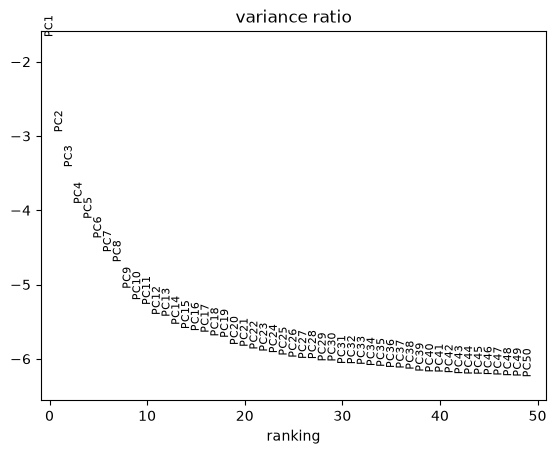

In [4]:
# Run PCA on the highly variable genes only
# svd_solver='arpack' works well with sparse data

sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')

print("PCA complete.")
print(f"PCA shape: {adata.obsm['X_pca'].shape}")

# Plot variance explained by each component
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [ ]:
# Compute neighbor graph using top 30 PCs
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

# Compute UMAP for visualization
sc.tl.umap(adata)

print("UMAP computed.")

/home/voldemort/anaconda3/envs/sle-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP computed.


In [6]:
sc.tl.leiden(adata, resolution=1.0)

print(f"Number of clusters found: {adata.obs['leiden'].nunique()}")
print("\nCells per cluster:")
print(adata.obs['leiden'].value_counts().sort_index())

/tmp/ipykernel_146601/2610306549.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0)


Number of clusters found: 18

Cells per cluster:
leiden
0     4673
1     4575
2     3961
3     3324
4     3233
5     2631
6     1955
7     1886
8     1793
9     1450
10    1315
11    1023
12     894
13     355
14     267
15     109
16      83
17      73
Name: count, dtype: int64


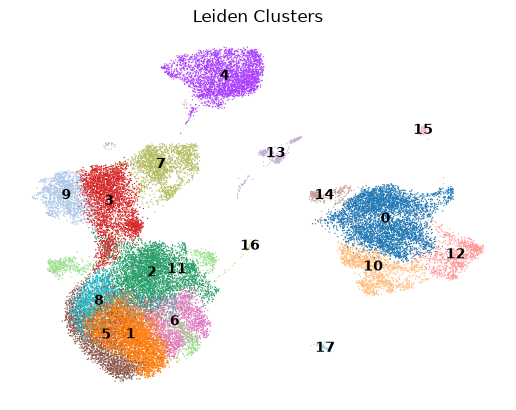

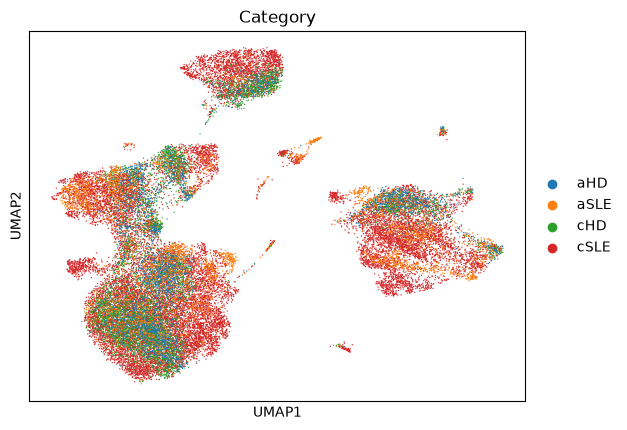

In [7]:
# UMAP colored by cluster
sc.pl.umap(adata, color='leiden', legend_loc='on data', 
           title='Leiden Clusters', frameon=False)

# UMAP colored by category
sc.pl.umap(adata, color='category', title='Category')

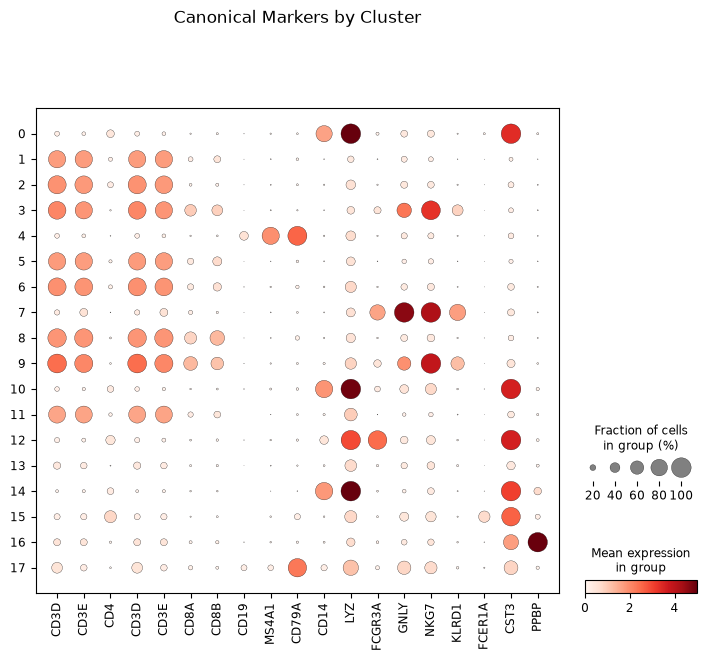

In [ ]:
# Define canonical markers for major PBMC cell types
marker_genes = {
    'CD4 T cell': ['CD3D', 'CD3E', 'CD4'],
    'CD8 T cell': ['CD3D', 'CD3E', 'CD8A', 'CD8B'],
    'B cell': ['CD19', 'MS4A1', 'CD79A'],
    'Monocyte': ['CD14', 'LYZ', 'FCGR3A'],
    'NK cell': ['GNLY', 'NKG7', 'KLRD1'],
    'DC': ['FCER1A', 'CST3'],
    'Platelet': ['PPBP'],
}

# Flatten the list for plotting
all_markers = [g for genes in marker_genes.values() for g in genes]

# Check which markers are actually in our dataset
present_markers = [g for g in all_markers if g in adata.var_names]
missing = set(all_markers) - set(present_markers)
if missing:
    print(f"Missing markers (may be named differently): {missing}")

# Dot plot: shows % of cells expressing each marker
sc.pl.dotplot(adata, present_markers, groupby='leiden', 
              title='Canonical Markers by Cluster')

Though some clusters can be meaningful to annotate to a cell from this figure but still can't be quite sure about most of the clusters, even clusters showing CD3 and CD4 expressions can't be distinguished if they are CD4+ or CD8+ T cells or not. That's why it got required to have the top genes list of all clusters to get to know further biology of those

In [9]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon')

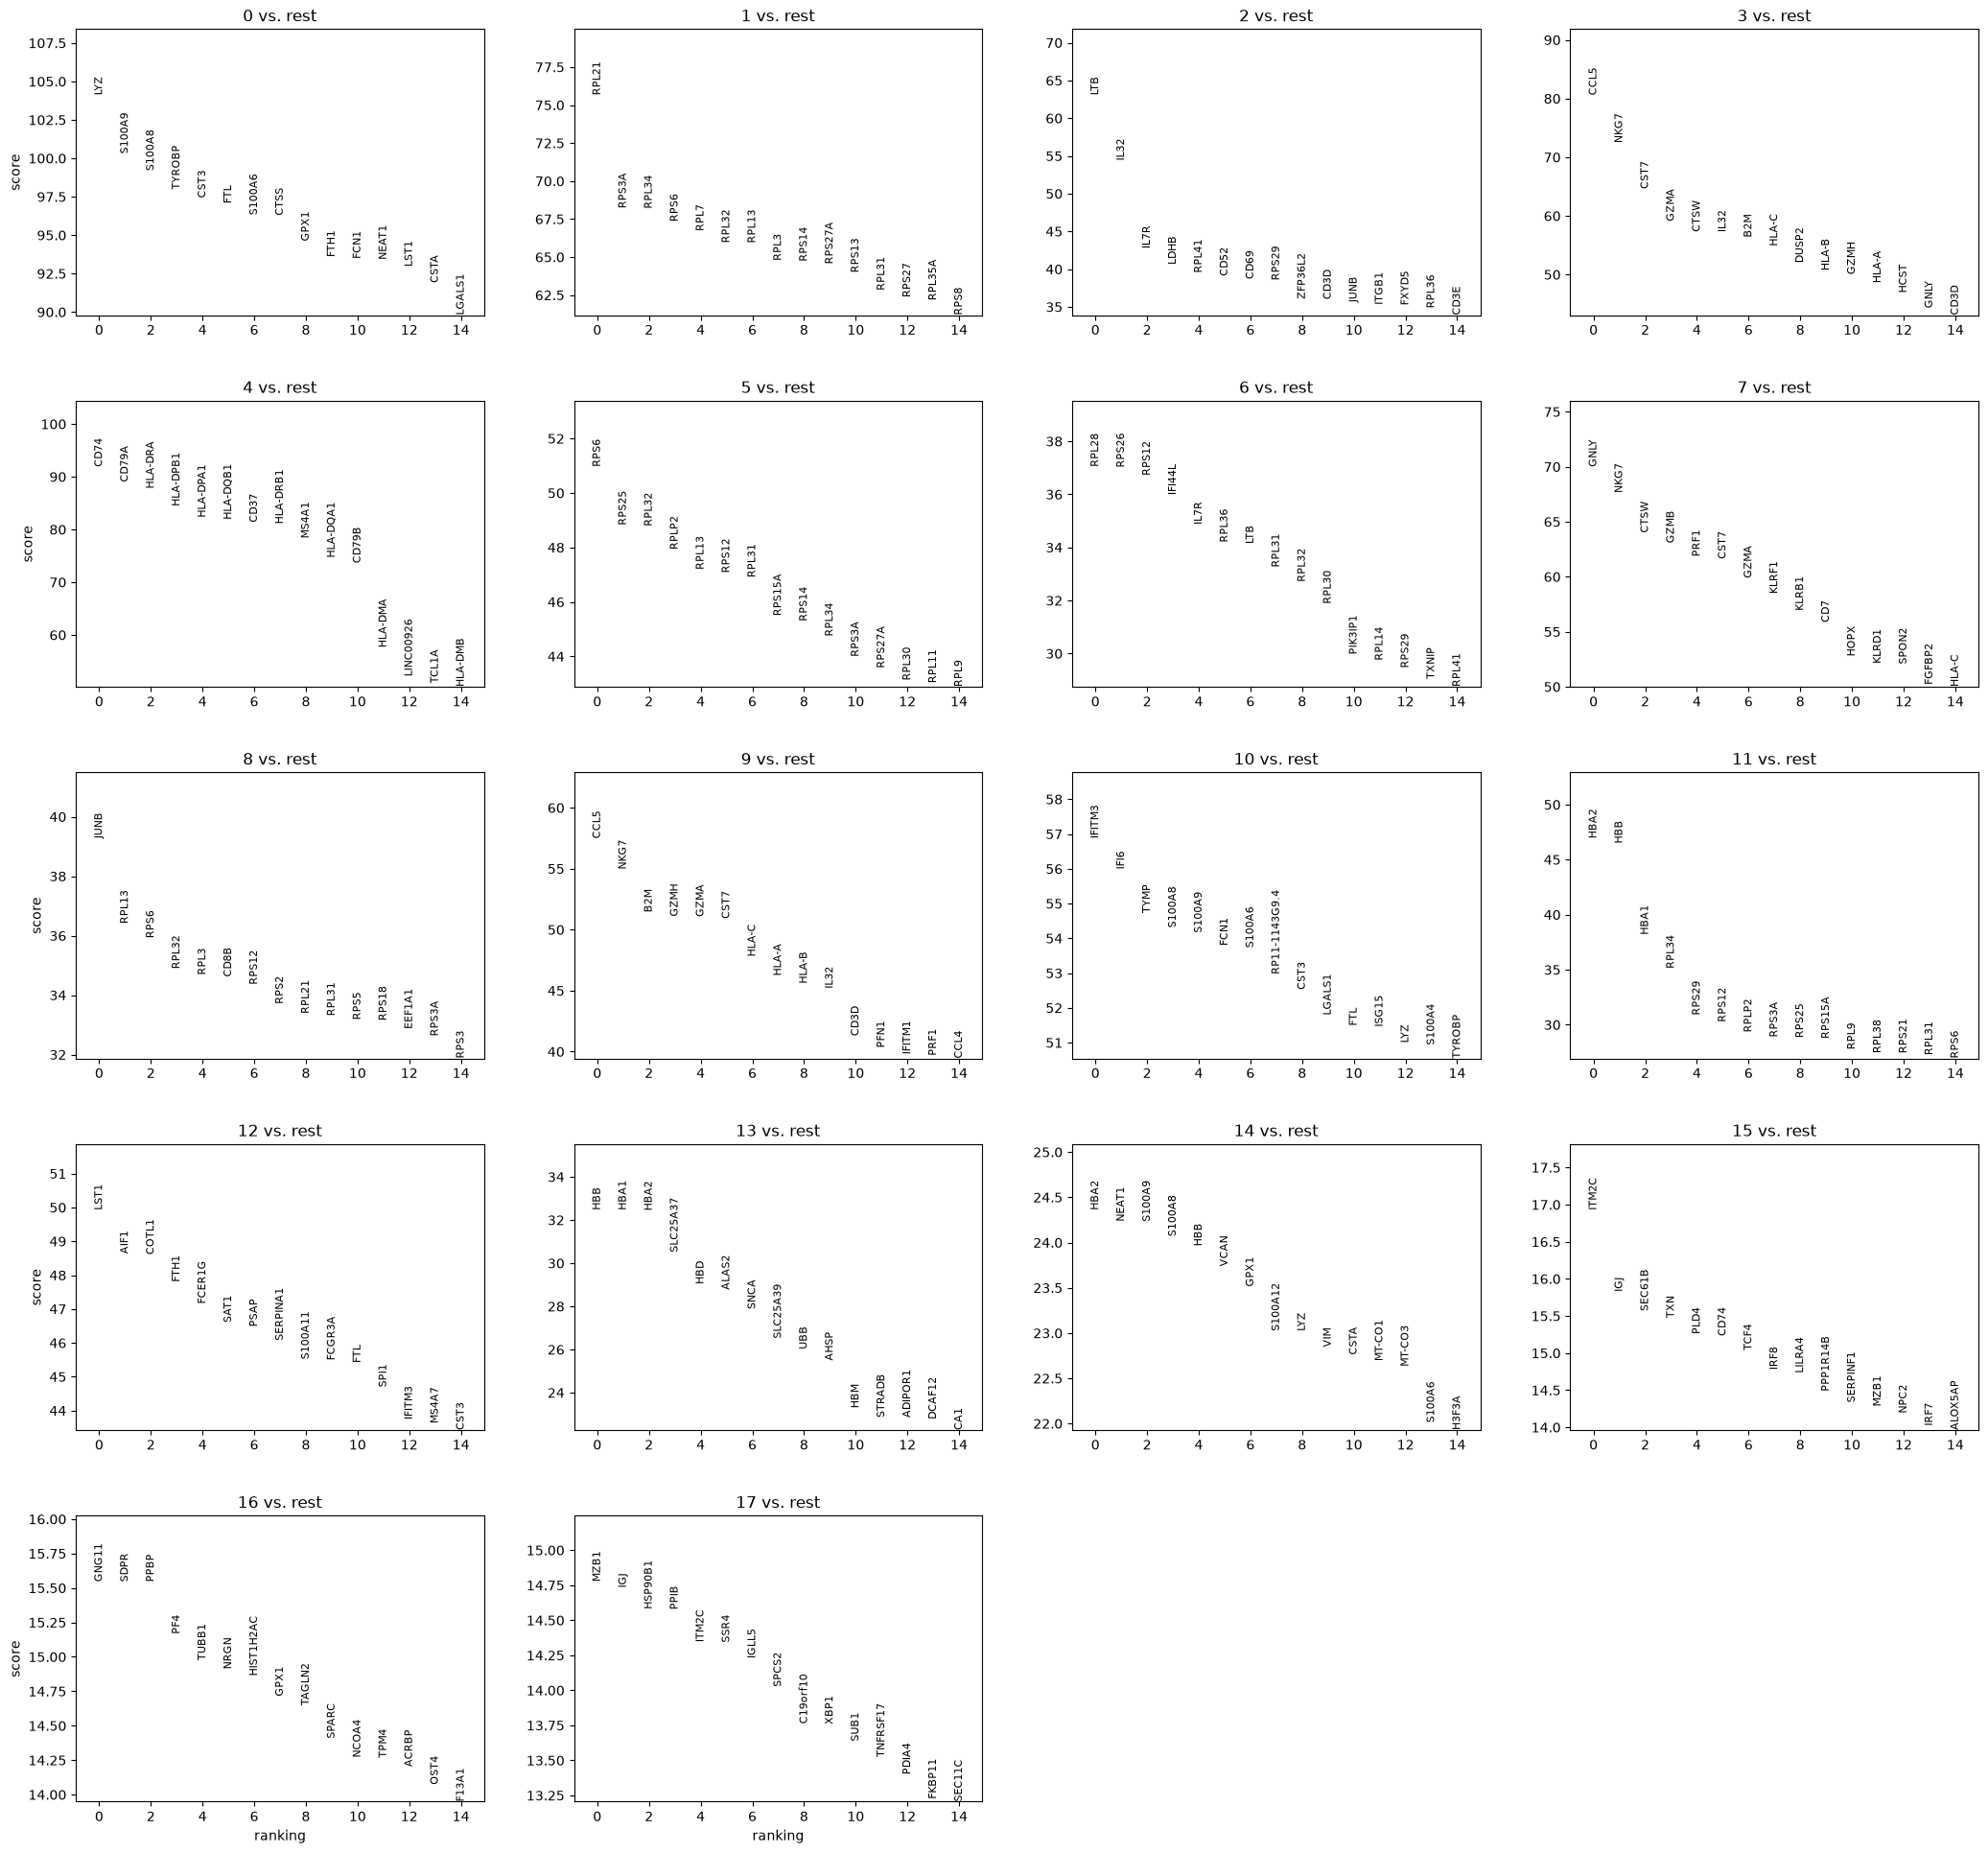

In [10]:
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)

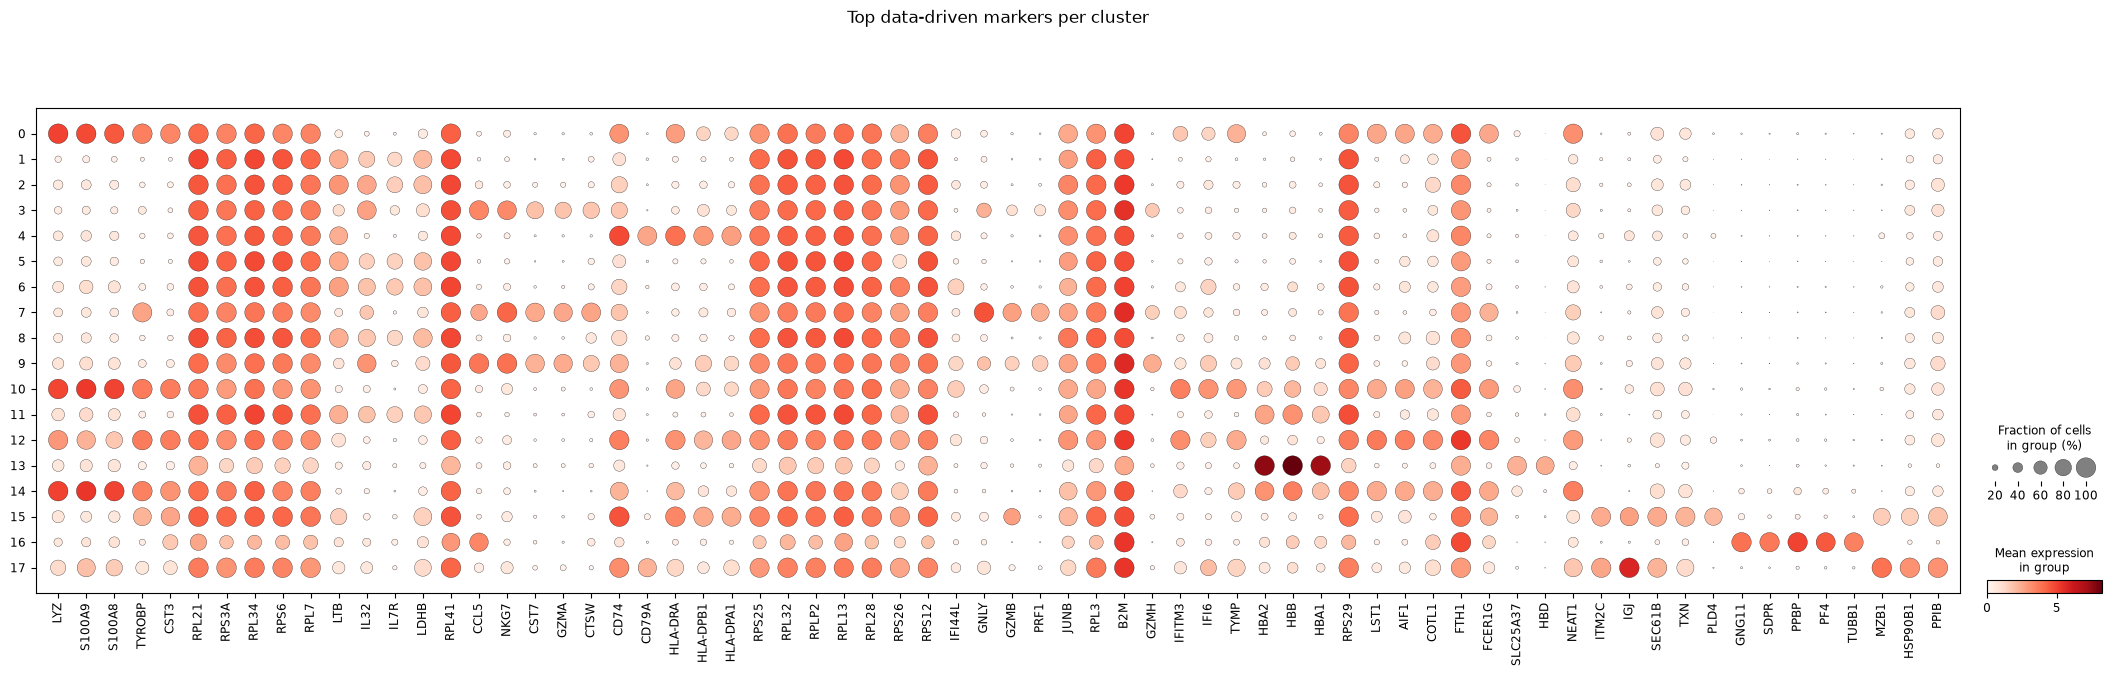

In [11]:
# Took top 5 genes from each cluster
top5_genes = []
for cluster in adata.obs['leiden'].cat.categories:
    genes = sc.get.rank_genes_groups_df(adata, group=cluster).head(5)['names'].tolist()
    top5_genes.extend(genes)

# TO remove duplicates while preserving order
top5_genes = list(dict.fromkeys(top5_genes))

sc.pl.dotplot(adata, var_names=top5_genes, groupby='leiden', 
              title='Top data-driven markers per cluster')

following clusters still need further investigation and that's why their top 20 genes are needed

In [13]:
clusters = ["1", "2", "3", "5", "6", "7", "8", "9", "11", "12", "15", "17"]

result = adata.uns["rank_genes_groups"]

deg_table = pd.DataFrame({
    cluster: result["names"][cluster][:20]
    for cluster in clusters
})

deg_table

,1,2,3,5,6,7,8,9,11,12,15,17
0,RPL21,LTB,CCL5,RPS6,RPL28,GNLY,JUNB,CCL5,HBA2,LST1,ITM2C,MZB1
1,RPS3A,IL32,NKG7,RPS25,RPS26,NKG7,RPL13,NKG7,HBB,AIF1,IGJ,IGJ
2,RPL34,IL7R,CST7,RPL32,RPS12,CTSW,RPS6,B2M,HBA1,COTL1,SEC61B,HSP90B1
3,RPS6,LDHB,GZMA,RPLP2,IFI44L,GZMB,RPL32,GZMH,RPL34,FTH1,TXN,PPIB
4,RPL7,RPL41,CTSW,RPL13,IL7R,PRF1,RPL3,GZMA,RPS29,FCER1G,PLD4,ITM2C
5,RPL32,CD52,IL32,RPS12,RPL36,CST7,CD8B,CST7,RPS12,SAT1,CD74,SSR4
6,RPL13,CD69,B2M,RPL31,LTB,GZMA,RPS12,HLA-C,RPLP2,PSAP,TCF4,IGLL5
7,RPL3,RPS29,HLA-C,RPS15A,RPL31,KLRF1,RPS2,HLA-A,RPS3A,SERPINA1,IRF8,SPCS2
8,RPS14,ZFP36L2,DUSP2,RPS14,RPL32,KLRB1,RPL21,HLA-B,RPS25,S100A11,LILRA4,C19orf10
9,RPS27A,CD3D,HLA-B,RPL34,RPL30,CD7,RPL31,IL32,RPS15A,FCGR3A,PPP1R14B,XBP1


clusters 0, 10, 14 all showed high expression of CD14, LYZ, CST3 -> pattern: classical monocytes 
cluster 4 with high expression of CD74, CD79A, HLA-DRA, HLA-DPB1, HLA-DPA1 -> pattern: B cells
cluster 15 FCER1A, CST3 can indicate it being myeloid cells
cluster 16 with GNG11, SDPR, PPBP, TUBB1 indicates -> pattern: platelets
cluster 2 have CCL5, NKG7, CST7, GZMA and specially FGFBP2 which highly associated with cytotoxic effector CD8+ T cells
cluster 3 has CD3D, CD3E, CCL5, NKG7, FGFBP2 which suggests it being cytotoxic CD8+ T cells
cluster 7 has GNLY, NKG7, GZMB, KLRF1, KLRD1, PRF1 which is NK cell signature
cluster 8 with almost same s cluster 7 but having CD3D means of its T cell identity, so it's cytotoxic CD8+ T cells
cluster 9 with HBA2, HBB, HBA1 in its top 20 genes suggest it being erythroid because of those hemoglobin genes
cluster 11's presence of GCGR3A with other genes suggest it can be non-classical monocytes
cluster 12 has LILRA4, TCF4, PLD4 which are indicators of plasmacytoid dendritic cells
cluster 13 with HBA1,HBA2, HBB can indicate it as erythroid contamination rather than a cell
cluster 17 with MZB1, XBP1, FKBP11 suggest it can be plasma cells

cluster 5 and 6 will need ranking 50 genes as with 20 genes most of the genes they are showing are ribosomal genes

In [14]:
result = adata.uns["rank_genes_groups"]

for cluster in ["5", "6"]:
    print(f"\nCLUSTER {cluster}")
    print(result["names"][cluster][:50])


CLUSTER 5
['RPS6' 'RPS25' 'RPL32' 'RPLP2' 'RPL13' 'RPS12' 'RPL31' 'RPS15A' 'RPS14'
 'RPL34' 'RPS3A' 'RPS27A' 'RPL30' 'RPL11' 'RPL9' 'RPL21' 'RPS28' 'RPS29'
 'RPS23' 'RPS18' 'RPL10' 'RPL5' 'RPL35A' 'RPS3' 'RPS13' 'RPS5' 'RPL13A'
 'RPS4X' 'RPL7' 'RPS16' 'RPS20' 'RPL38' 'RPL3' 'RPL19' 'RPL10A' 'RPL22'
 'RPL27A' 'RPS27' 'RPL36' 'RPS21' 'RPL18' 'RPS8' 'RPL4' 'RPL14' 'RPL18A'
 'RPL37' 'RPL39' 'EEF1A1' 'EEF1B2' 'RPL23A']

CLUSTER 6
['RPL28' 'RPS26' 'RPS12' 'IFI44L' 'IL7R' 'RPL36' 'LTB' 'RPL31' 'RPL32'
 'RPL30' 'PIK3IP1' 'RPL14' 'RPS29' 'TXNIP' 'RPL41' 'RPL12' 'RPS25' 'RPSA'
 'RPL11' 'RPL36A' 'RPL35A' 'RPS28' 'RPS15' 'CD3E' 'RPLP1' 'RPL13' 'RPS10'
 'RPS18' 'RPL38' 'IFITM1' 'RPL37' 'SELL' 'CD3D' 'LDHB' 'RPS21' 'RPSAP58'
 'MALAT1' 'CCR7' 'RPL37A' 'RPLP0' 'RPS20' 'RPLP2' 'RPL23A' 'NOSIP' 'IFI6'
 'RPS19' 'C6orf48' 'LEF1' 'RPL10A' 'OXNAD1']


IL7R, LTB, CCR7, CD62L, LEF1 in cluster 6 suggests it can be naive or central memory T cell
cluster 5 do have T cell markers but with lots of ribosomal genes, so it might be a stressed T cell population. Further investigation is needed to clarify the identity of these clusters.

with all those informations, created the following dictionary with cluster annotations

In [ ]:
cluster_annotations = {
    "0": "Classical monocytes",
    "1": "T cells",
    "2": "Cytotoxic CD8+ T cells",
    "3": "Cytotoxic CD8+ T cells",
    "4": "B cells",
    "5": "T cells",
    "6": "Naive/central-memory CD4+ T cells",
    "7": "NK cells",
    "8": "Cytotoxic CD8+T cells",
    "9": "Erythroid / RBC-like",
    "10": "Classical monocytes",
    "11": "Non-classical monocytes",
    "12": "Plasmacytoid dendritic cells",
    "13": "Erythroid / RBC-like",
    "14": "Classical monocytes",
    "15": "Myeloid cells",
    "16": "Platelets",
    "17": "Plasma cells"
}


# Apply labels
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotations)

# Fill any unmapped clusters with "Unknown"
adata.obs['cell_type'] = adata.obs['cell_type'].fillna('Unknown')

print("Cell type counts:")
print(adata.obs['cell_type'].value_counts())

Cell type counts:
cell_type
Cytotoxic CD8+ T cells               7285
T cells                              7206
Classical monocytes                  6255
B cells                              3233
Naive/central-memory CD4+ T cells    1955
NK cells                             1886
Erythroid / RBC-like                 1805
Cytotoxic CD8+T cells                1793
Non-classical monocytes              1023
Plasmacytoid dendritic cells          894
Myeloid cells                         109
Platelets                              83
Plasma cells                           73
Name: count, dtype: int64


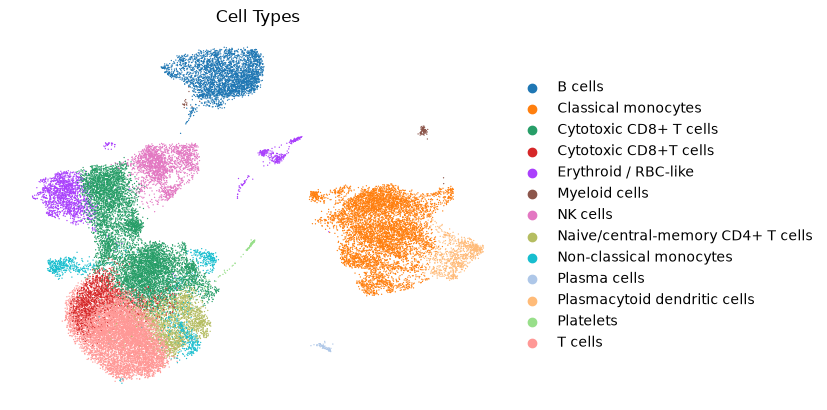

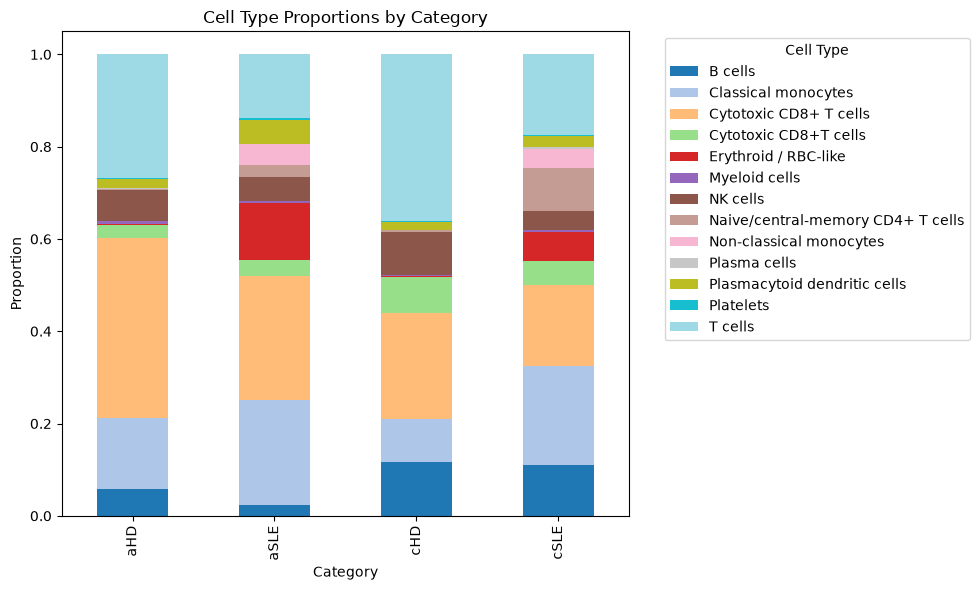

In [17]:
# UMAP colored by cell type
sc.pl.umap(adata, color='cell_type', title='Cell Types', frameon=False)

# Stacked bar plot: cell type proportions by category
ct_props = pd.crosstab(adata.obs['category'], adata.obs['cell_type'], normalize='index')
ct_props.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Cell Type Proportions by Category')
plt.ylabel('Proportion')
plt.xlabel('Category')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../results/figures/cell_type_proportions.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
adata.write("../data/processed/GSE135779_annotated.h5ad")
print("Saved annotated dataset.")

Saved annotated dataset.
